In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.gridspec as gridspec

sys.path.append(str(Path("../PROF/data_analysis").resolve()))

from build_panel import load_panel_acc, load_panel_prof
from plot_style_utils import apply_plot_theme, style_axis, PALETTE

In [3]:
#=======================================
# LOAD DATA
#=======================================

panel_acc = load_panel_acc()
panel_prof = load_panel_prof()

panel = pd.merge(
    panel_acc,
    panel_prof[["Ticker", "Year", "REVT"]],
    on=["Ticker", "Year"],
    how="left"
)

panel = panel.sort_values(["Ticker", "Year"])

print(f"Panel loaded: {len(panel):,} firm-years")
print(f"Firms: {panel["Ticker"].nunique()}")

Panel loaded: 9,866 firm-years
Firms: 641


In [4]:
#=======================================
# WORKING CAPITAL ACCRUALS
#=======================================

grp = panel.groupby("Ticker", sort=False)

delta_ca = grp["ACT"].diff()
delta_cash = grp["CHE"].diff()
delta_cl = grp["LCT"].diff()
delta_std = grp["STD"].diff()
delta_tp = grp["TXP"].diff()

panel["WCAcc_raw"] = (
    (delta_ca - delta_cash)
    - (delta_cl - delta_std - delta_tp)
)

panel["at_lag"] = grp["AT"].shift(1)

panel["WCAcc"] = (
    panel["WCAcc_raw"] / panel["at_lag"].replace(0, np.nan)
)

In [5]:
#=======================================
# REGRESSION VARIABLES
#=======================================

at_lag = panel["at_lag"].replace(0, np.nan)

panel["CFO_t"] = panel["OANCF"] / at_lag
panel["CFO_tm1"] = grp["CFO_t"].shift(1)
panel["CFO_tm1_scaled"] = grp["OANCF"].shift(1) / at_lag

panel["delta_revt"] = grp["REVT"].diff() / at_lag

panel["PPEGT_scaled"] = panel["PPEGT"] / at_lag

REGRESSORS = ["CFO_tm1_scaled", "CFO_t", "delta_revt", "PPEGT_scaled"]
DEPENDENT = "WCAcc"

In [6]:
#=======================================
# CROSS-SECTIONAL OLS BY YEAR
#=======================================

residuals = pd.Series(np.nan, index=panel.index)
year_results = []

MIN_FIRMS_PER_YEAR = 20

for year, group in panel.groupby(panel["Year"]):

    reg_cols = [DEPENDENT] + REGRESSORS
    sub = group[reg_cols].dropna()

    if len(sub) < MIN_FIRMS_PER_YEAR:
        year_results.append({
            'year': year, 'n': len(sub),
            'r2': np.nan, 'status': 'SKIP (too few obs)'
        })
        continue

    y = sub[DEPENDENT].values
    X = sub[REGRESSORS].values

    # OLS via numpy for speed
    X_aug = np.column_stack([np.ones(len(X)), X])
    try:
        b, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)
    except np.linalg.LinAlgError:
        year_results.append({
            'year': year, 'n': len(sub),
            'r2': np.nan, 'status': 'ERROR'
        })
        continue
    
    fitted = X_aug @ b
    resid  = y - fitted

    # R-squared
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Store residuals aligned to original panel index
    residuals.loc[sub.index] = resid

    year_results.append({
        'year': year, 'n': len(sub), 'r2': r2,
        'alpha': b[0],
        'b_cfo_lag': b[1], 'b_cfo_cur': b[2],
        'b_drev': b[3],    'b_ppe': b[4],
        'status': 'OK'
    })


panel['dd_residual'] = residuals

yr_df = pd.DataFrame(year_results).set_index('year')
n_ok  = (yr_df['status'] == 'OK').sum()
print(f'Regressions run: {n_ok} / {len(yr_df)} years succeeded')
print(f'Residuals: {panel["dd_residual"].notna().sum():,} non-null')


Regressions run: 19 / 20 years succeeded
Residuals: 3,548 non-null


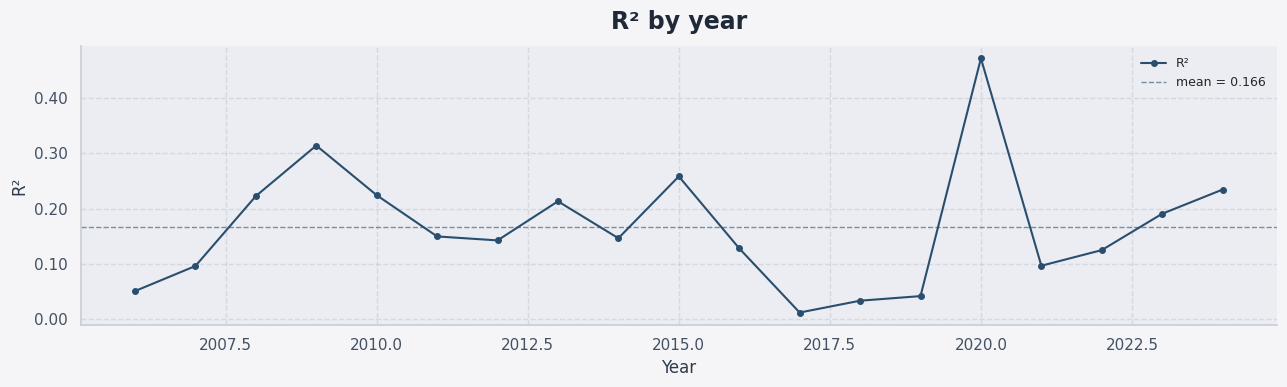

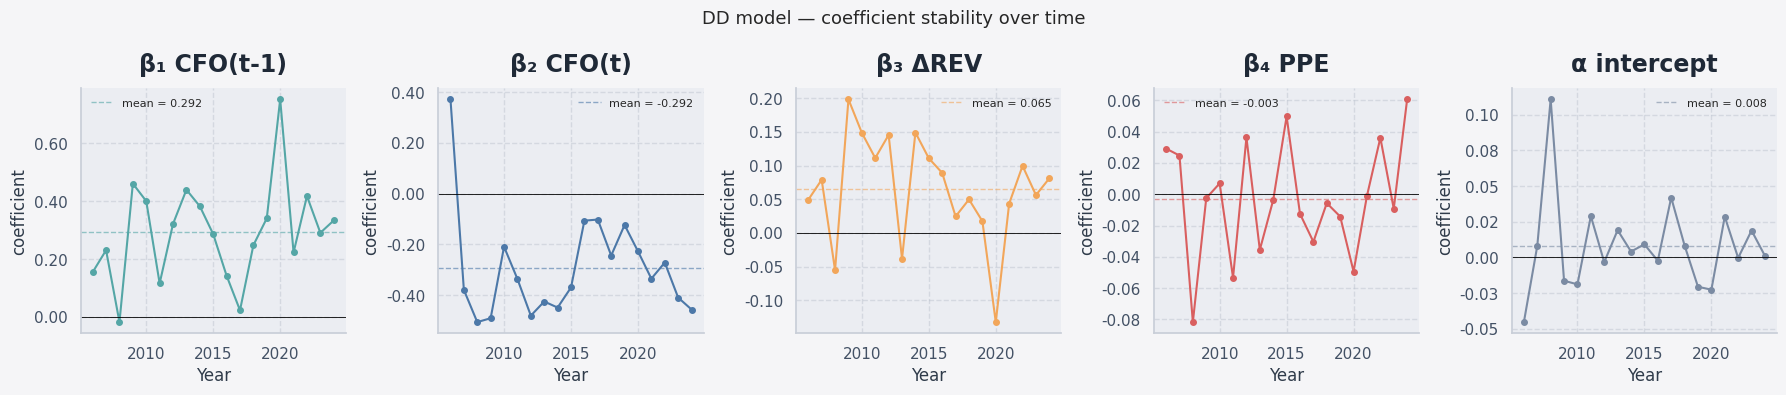


Average R²: 0.166
        n     r2  alpha  b_cfo_lag  b_cfo_cur  b_drev  b_ppe
year                                                        
2006   37  0.051 -0.045      0.155      0.372   0.049  0.029
2007   50  0.096  0.008      0.231     -0.379   0.079  0.025
2008   62  0.223  0.111     -0.018     -0.506  -0.055 -0.082
2009   62  0.314 -0.016      0.461     -0.491   0.199 -0.003
2010   72  0.224 -0.019      0.400     -0.209   0.149  0.007
2011   89  0.150  0.029      0.116     -0.336   0.111 -0.053
2012  116  0.143 -0.003      0.322     -0.481   0.146  0.036
2013  146  0.213  0.019      0.440     -0.425  -0.038 -0.036
2014  169  0.147  0.004      0.383     -0.449   0.149 -0.004
2015  173  0.258  0.009      0.286     -0.370   0.111  0.050
2016  187  0.128 -0.002      0.142     -0.106   0.089 -0.013
2017  210  0.012  0.042      0.023     -0.102   0.025 -0.030
2018  223  0.034  0.008      0.248     -0.244   0.050 -0.006
2019  241  0.042 -0.021      0.341     -0.123   0.018 -0.014
2020 

In [ ]:
apply_plot_theme()

yr_ok = yr_df[yr_df["status"] == "OK"]
fmt_decimal = plt.FuncFormatter(lambda x, _: f"{x:.2f}")

COEF_DEFS = [
    ("b_cfo_lag", "β₁ CFO(t-1)", PALETTE["teal"]),
    ("b_cfo_cur", "β₂ CFO(t)",   PALETTE["blue"]),
    ("b_drev",    "β₃ ΔREV",     PALETTE["orange"]),
    ("b_ppe",     "β₄ PPE",      PALETTE["red"]),
    ("alpha",     "α intercept", PALETTE["slate"]),
]

# ── Figure 1: R² ──────────────────────────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(13, 4))
ax.plot(yr_ok.index, yr_ok["r2"], "o-", color=PALETTE["navy"], lw=1.5, ms=4, label="R²")
ax.axhline(yr_ok["r2"].mean(), color=PALETTE["navy"], lw=1, ls="--", alpha=0.6,
           label=f"mean = {yr_ok['r2'].mean():.3f}")
style_axis(ax, title="R² by year", xlabel="Year", ylabel="R²")
ax.yaxis.set_major_formatter(fmt_decimal)
ax.legend(fontsize=9)
fig1.tight_layout()
plt.show()

# ── Figure 2: coefficients ────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig2.suptitle("Coefficient stability over time", fontsize=13)

for ax, (col, lbl, clr) in zip(axes, COEF_DEFS):
    ax.plot(yr_ok.index, yr_ok[col], "o-", color=clr, lw=1.5, ms=4)
    ax.axhline(yr_ok[col].mean(), color=clr, lw=1, ls="--", alpha=0.6,
               label=f"mean = {yr_ok[col].mean():.3f}")
    ax.axhline(0, color="black", lw=0.6)
    style_axis(ax, title=lbl, xlabel="Year", ylabel="coefficient")
    ax.yaxis.set_major_formatter(fmt_decimal)
    ax.legend(fontsize=8)

fig2.tight_layout()
plt.show()

print(f"\nAverage R²: {yr_ok['r2'].mean():.3f}")
print(yr_ok[["n", "r2", "alpha", "beta_cfo_lag", "beta_cfo_cur", "beta_drev", "beta_ppe"]].round(3).to_string())